In [1]:
import math
import numpy as np
import seaborn as sns

from rl_firm.abm.parameter import ModelParameters, FirmParameters, HouseholdParameters
from rl_firm.abm.firm import Firm, LearningFirm
from rl_firm.abm.household import Household
from rl_firm.abm.model import BaselineModel

# Run the model

In [2]:
parameters = ModelParameters(
    month_length = 21,
    initial_employment_rate = 0.0,
    n_firms = 100,
    n_learning_firms = 0,
    n_households = 1000,
    burn_in_months = 1000,
    
    firm = FirmParameters(
        gamma_consecutive_months = 24,
        delta_wage_adjustment_rate = 0.019,
        upper_phi_demand = 1,
        lower_phi_demand = 0.25,
        upper_phi_marginal_cost = 1.15,
        lower_phi_marginal_cost = 1.025,
        theta_goods_price = 0.02,
        theta_probs_set_new_price = 0.75,
        lambda_technology = 3,
        chi_buffer = 0.1,

        initial_open_position = True,
        initial_liquidity = 0,
        initial_goods_price = 40,
        initial_wage_rate = 2000,
        #initial_goods_price = 10,
        #initial_wage_rate = 600,
    ),

    household = HouseholdParameters(
        xi_price_percentage = 0.01,
        beta_firm_count = 5,
        pi_explore_odd = 0.1,
        alpha_budget_exponent = 0.9,
        n_suppliers = 7,
        psi_price = 0.25,
        psi_quant = 0.25,

        initial_reservation_wage = 0,
        initial_liquidity = 5000,
    )
)

model = BaselineModel(parameters=parameters)

### Burn in

In [3]:
%%time

model.burn_in()

CPU times: user 1min 44s, sys: 455 ms, total: 1min 45s
Wall time: 1min 45s


In [4]:
[(f.unique_id, f.profit_ranking, round(f.goods_price, 2), round(f.wage_rate, 2), round(f.last_month_profit, 2), round(f.inventories, 2), f.employee_count, f.customer_count) for f in model.firms]

[(1, 84, 42.16, 1947.51, 0.0, 0.0, 0, 33),
 (2, 13, 42.04, 2280.8, 8070.42, 75.1, 23, 71),
 (3, 16, 42.13, 2305.76, 7883.7, 69.0, 23, 266),
 (4, 6, 42.35, 2261.24, 9632.83, 15.0, 5, 22),
 (5, 36, 41.87, 2282.81, 4968.96, 42.0, 14, 250),
 (6, 33, 41.75, 2286.06, 5503.99, 48.0, 16, 128),
 (7, 35, 41.7, 2279.32, 5343.44, 45.0, 15, 65),
 (8, 69, 41.34, 2260.62, 1002.82, 18.01, 4, 18),
 (9, 85, 42.47, 1763.63, 0.0, 0.0, 0, 3),
 (10, 62, 42.26, 2257.31, 2152.02, 15.0, 5, 87),
 (11, 15, 41.91, 2288.23, 7971.14, 69.0, 23, 76),
 (12, 39, 42.09, 2270.3, 4825.26, 36.0, 12, 88),
 (13, 42, 41.49, 2268.8, 4702.97, 42.0, 14, 122),
 (14, 54, 41.65, 2274.3, 3047.52, 24.0, 8, 37),
 (15, 64, 42.95, 2300.2, 1494.85, 12.0, 4, 30),
 (16, 80, 42.73, 2305.58, 234.13, 338.19, 14, 34),
 (17, 56, 41.55, 2273.76, 2877.33, 24.0, 8, 222),
 (18, 17, 42.23, 2273.58, 7095.85, 54.0, 18, 154),
 (19, 11, 41.57, 2276.94, 8214.03, 72.0, 24, 106),
 (20, 61, 42.56, 2256.79, 2172.52, 15.0, 5, 16),
 (21, 67, 43.15, 2238.7, 117

In [5]:
sorted([f.last_month_profit for f in model.firms])

[-2213.7068362556165,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0,
 0.0,
 0,
 0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 125.80933231733675,
 167.25659520451617,
 200.68705818633725,
 234.1264965510054,
 249.0141607828358,
 395.3140179164079,
 542.3457400144343,
 613.0666544136848,
 713.8464434462112,
 722.2464092547937,
 796.4071263749574,
 811.7570552079569,
 892.4557040499867,
 968.7142166785034,
 1002.8177197459736,
 1057.885415749569,
 1179.2511156531955,
 1268.7815578131049,
 1428.5531629752268,
 1494.849891600501,
 2145.2768608046063,
 2152.021786937763,
 2172.5205823431224,
 2185.6176020478615,
 2293.3177361643466,
 2686.377189873894,
 2708.8508811257816,
 2877.332979742474,
 2899.552646263026,
 3047.5153605859377,
 3101.464685724808,
 3109.0308727208358,
 3312.990312721482,
 3518.072081400511,
 4125.495713695229,
 4149.882394477034,
 4191.597346812276,
 4245.820804439478,
 4422.511032823502,
 4437.9822174211,
 4558.049877604778,
 4702.971862812363,
 4738.383652591434,
 4804.8849446189

In [6]:
sum([f.last_month_profit for f in model.firms]) / len(model.firms)

3772.1549871805987

In [7]:
np.tanh(8000 / 50000)

np.float64(0.1586485042974989)

In [8]:
np.median([f.last_month_profit for f in model.firms])

np.float64(3415.5311970609964)

### True run

In [9]:
%%time

YEARS = 100

for _ in range(YEARS * 12 * 21):
    model.step()

CPU times: user 2min 6s, sys: 445 ms, total: 2min 7s
Wall time: 2min 8s


In [10]:
[(f.unique_id, round(f.goods_price, 2), round(f.wage_rate, 2), round(f.last_month_profit, 2), round(f.inventories, 2), f.employee_count) for f in model.firms]

[(1, 44.56, 2364.48, 4118.56, 27.0, 9),
 (2, 45.39, 2307.81, 6270.62, 42.12, 6),
 (3, 44.94, 2414.09, 429.57, 688.78, 12),
 (4, 46.31, 2085.94, 138.94, 0.0, 0),
 (5, 44.06, 2392.93, 5990.0, 48.0, 16),
 (6, 45.71, 2297.6, 6291.44, 184.19, 4),
 (7, 44.53, 2402.02, 10755.81, 81.0, 27),
 (8, 46.13, 1017.84, 0.0, 0.0, 0),
 (9, 45.6, 2354.21, 1419.78, 9.0, 3),
 (10, 44.85, 2405.97, 18450.96, 132.0, 44),
 (11, 45.61, 2401.01, 10514.43, 194.96, 28),
 (12, 45.12, 2103.67, 738.85, 3.0, 1),
 (13, 45.99, 2110.94, 0.0, 233.6, 6),
 (14, 44.94, 2383.75, 3823.0, 306.6, 12),
 (15, 45.85, 1890.83, 0.0, 0.0, 0),
 (16, 45.58, 2190.99, 680.29, 3.0, 1),
 (17, 44.83, 2316.89, 5718.76, 33.0, 11),
 (18, 45.2, 2385.79, -677.92, 197.98, 11),
 (19, 45.4, 2359.32, 7014.66, 42.0, 14),
 (20, 45.02, 2401.71, 9618.85, 87.11, 24),
 (21, 45.48, 2351.48, 5653.34, 33.0, 11),
 (22, 45.22, 1407.32, 0.0, 0.0, 0),
 (23, 45.1, 2261.09, 1160.32, 6.0, 2),
 (24, 45.4, 1986.47, 0.0, 0.0, 0),
 (25, 45.13, 2380.54, 7262.81, 48.0, 16

In [11]:
%%time

YEARS = 900

for _ in range(YEARS * 12 * 21):
    model.step()

CPU times: user 19min 31s, sys: 6.01 s, total: 19min 37s
Wall time: 19min 55s


In [12]:
[(f.unique_id, round(f.goods_price, 2), round(f.wage_rate, 2), round(f.last_month_profit, 2), round(f.inventories, 2), f.employee_count, f.open_position) for f in model.firms]

[(1, 44.72, 2111.41, 0.0, 0.0, 0, True),
 (2, 44.39, 2458.65, 8992.13, 81.0, 27, False),
 (3, 45.11, 2455.76, 6427.51, 51.0, 17, False),
 (4, 44.94, 2453.6, 3188.39, 18.0, 6, False),
 (5, 41.78, 2000.36, 0.0, 0.0, 0, True),
 (6, 44.65, 2467.43, 3322.19, 30.0, 10, False),
 (7, 44.5, 2434.88, 4822.43, 36.0, 12, True),
 (8, 44.64, 2435.92, 5783.95, 45.0, 15, False),
 (9, 44.72, 2435.51, 2920.61, 24.0, 8, False),
 (10, 44.96, 2452.75, 9869.32, 78.0, 26, False),
 (11, 42.88, 2364.26, 0.0, 0.0, 0, True),
 (12, 44.87, 2466.13, 3019.19, 24.0, 8, True),
 (13, 45.05, 2446.95, 8602.66, 66.0, 22, False),
 (14, 45.08, 2457.44, 1778.18, 15.0, 5, False),
 (15, 44.61, 2435.74, 7522.16, 62.01, 6, False),
 (16, 45.14, 2333.27, 0.0, 0.0, 0, True),
 (17, 44.74, 2444.79, 1360.73, 12.0, 4, False),
 (18, 45.87, 2470.34, 9507.75, 69.0, 23, False),
 (19, 44.91, 2464.01, 4983.64, 42.0, 14, False),
 (20, 44.15, 2401.11, 0.0, 0.0, 0, True),
 (21, 44.93, 2454.72, 5126.92, 42.0, 14, False),
 (22, 44.75, 2442.33, 93

In [13]:
sum([len(f.employees) for f in model.firms])

1000

In [14]:
len(set([hh.employer for hh in model.households]))

71

In [15]:
len([f for f in model.firms if f.employees])

71

# Data analysis

In [16]:
# Extract model data in a Pandas dataframe
df_daily = model.daily_data_collector.get_model_vars_dataframe()
df_daily['Year'] = df_daily.index // 252
df_daily['Month'] = df_daily.index // 21


# Aggregate by months
df_monthly = model.monthly_data_collector.get_model_vars_dataframe()
df_monthly['Gini'] = df_daily.groupby('Month').mean()['Gini']
df_monthly['Year'] = df_monthly.index // 12
df_monthly['Delta price'] = df_monthly['Price'].shift(-1) - df_monthly['Price']
df_monthly['Unemployed'] = 1000 - df_monthly['Employed']
df_monthly['Vacancy rate'] = df_monthly['Vacancies'] / (df_monthly['Vacancies'] + df_monthly['Unemployed'])

# Aggregate by years
df_yearly = df_monthly.groupby('Year').mean()
df_yearly['Delta price'] = df_yearly['Price'].shift(-1) - df_yearly['Price']
df_yearly['Inflation'] = (df_yearly['Price'].shift(-1) - df_yearly['Price']) / df_yearly['Price'] * 100
df_yearly['Unemployment rate'] = df_yearly['Unemployed'] / 1000 * 100

### Phillips and Beveridge

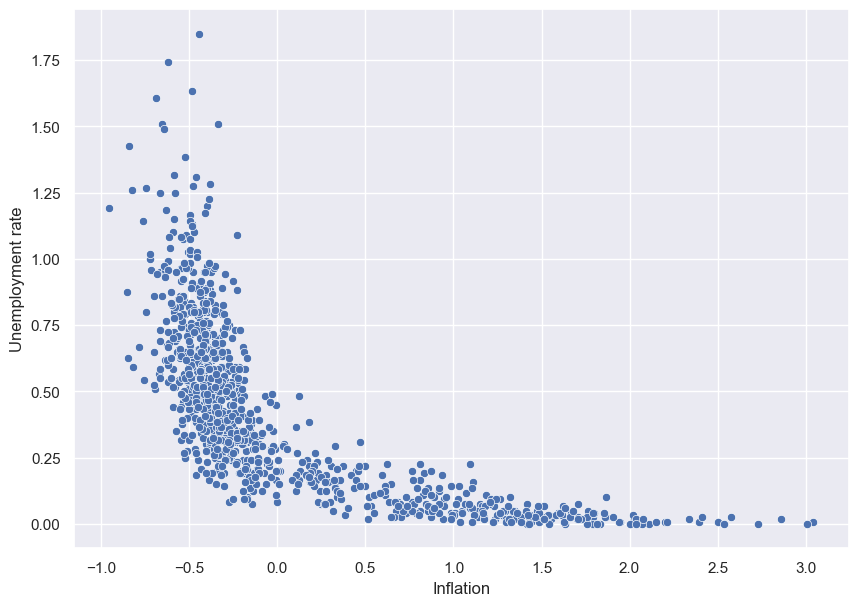

In [17]:
def plot_phillips(df_yearly):
    sns.set_theme(rc={'figure.figsize': (10, 7)})
    sns.scatterplot(data=df_yearly, x="Inflation", y="Unemployment rate")

plot_phillips(df_yearly)

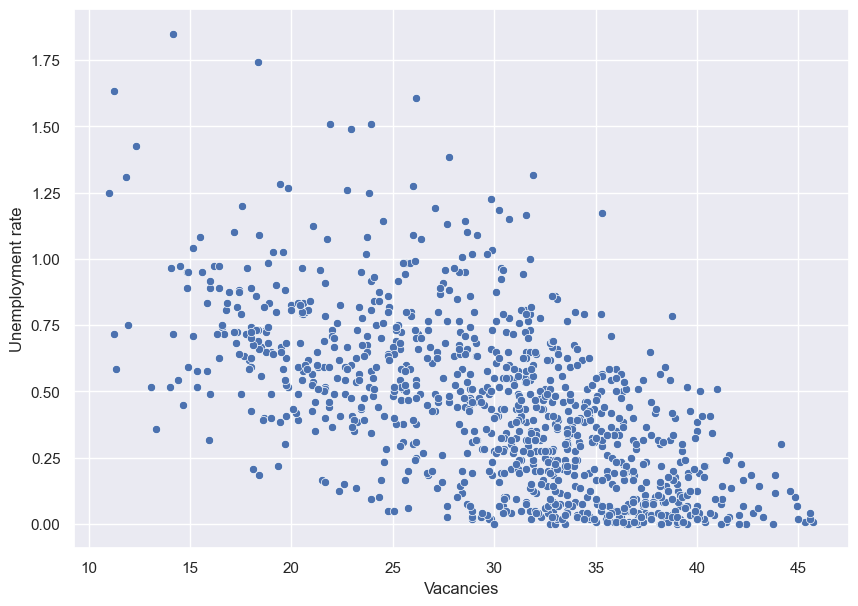

In [18]:
def plot_beveridge(df_yearly):
    sns.set_theme(rc={'figure.figsize': (10, 7)})
    sns.scatterplot(data=df_yearly, x="Vacancies", y="Unemployment rate")

plot_beveridge(df_yearly)

### Unsatisfied demand

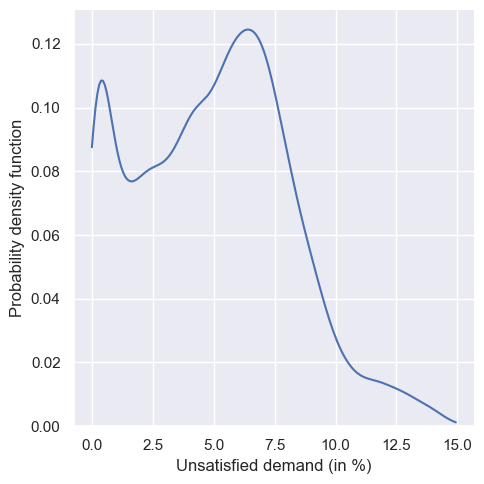

In [19]:
def plot_unsatisfied_demand(df_monthly, to_year=math.inf, from_year=0):
    sns.set_theme(rc={'figure.figsize': (10, 7)})
    g = sns.displot(data=df_monthly['Unsatisfied demand'] * 100, kind="kde", cut=0)
    g.set(xlabel='Unsatisfied demand (in %)')
    g.set(ylabel='Probability density function')

plot_unsatisfied_demand(df_monthly)

In [20]:
df_monthly['Unsatisfied demand'].max()

np.float64(0.14936537903624802)

### Statistics

In [21]:
def plot_monthly(df_monthly, column_name, to_year=math.inf, from_year=0):
    sns.set_theme(rc={'figure.figsize': (20, 5)})
    data = df_monthly[df_monthly['Year'].between(from_year, to_year)]
    g = sns.lineplot(data=data, x=data.index/12.0, y=column_name)
    g.set(title=f'{column_name} monthly', ylabel=column_name, xlabel='Year')

In [22]:
def plot_yearly(df_monthly, column_name, to_year=math.inf, from_year=0):
    sns.set_theme(rc={'figure.figsize': (20, 5)})
    data = df_monthly[df_monthly['Year'].between(from_year, to_year)][[column_name, 'Year']].groupby('Year').mean()
    g = sns.lineplot(data=data, x='Year', y=column_name)
    g.set(title=f'{column_name} over time', ylabel=column_name, xlabel='Year')

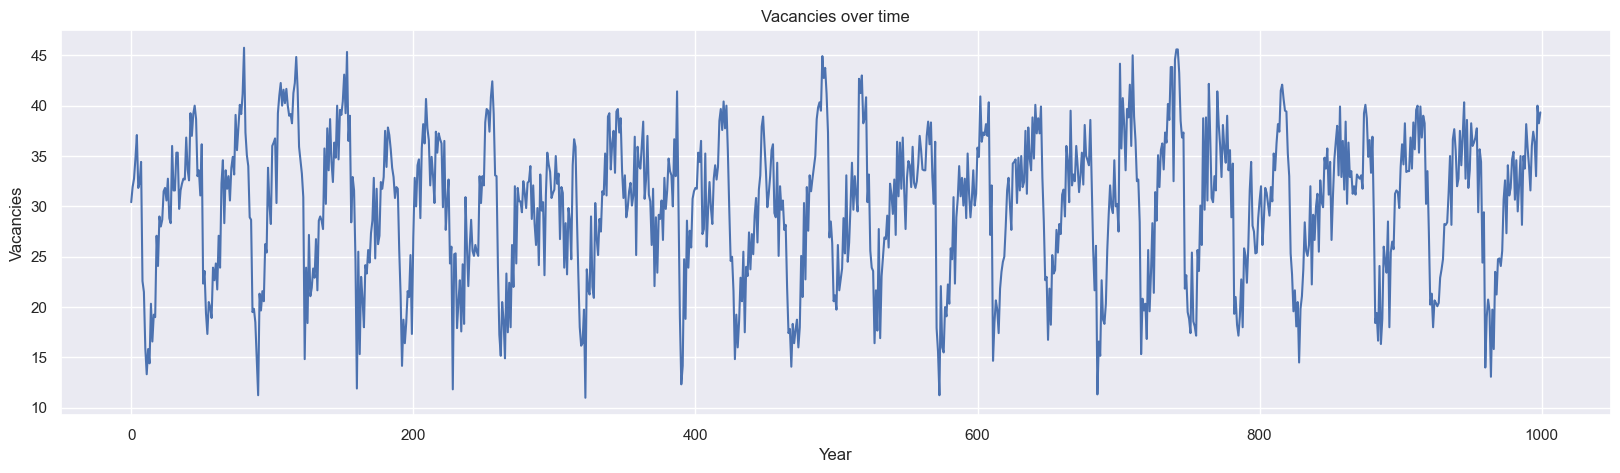

In [23]:
plot_yearly(df_monthly, 'Vacancies', to_year=1000, from_year=0)

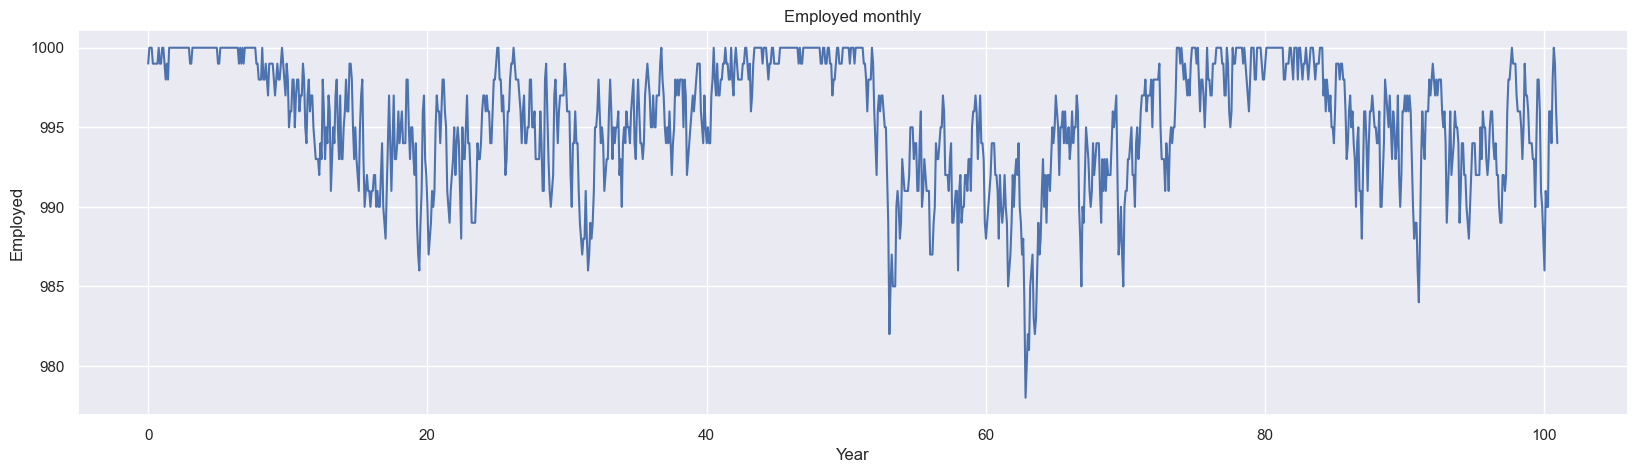

In [24]:
plot_monthly(df_monthly, 'Employed', to_year=100)

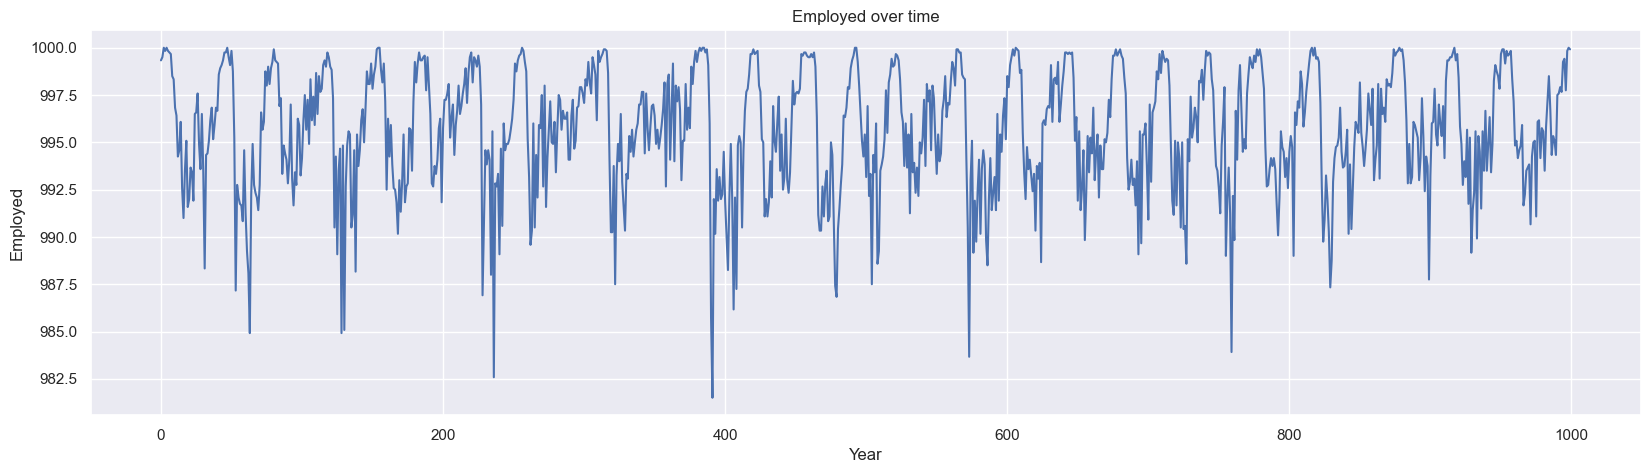

In [27]:
plot_yearly(df_monthly, 'Employed', to_year=1000)

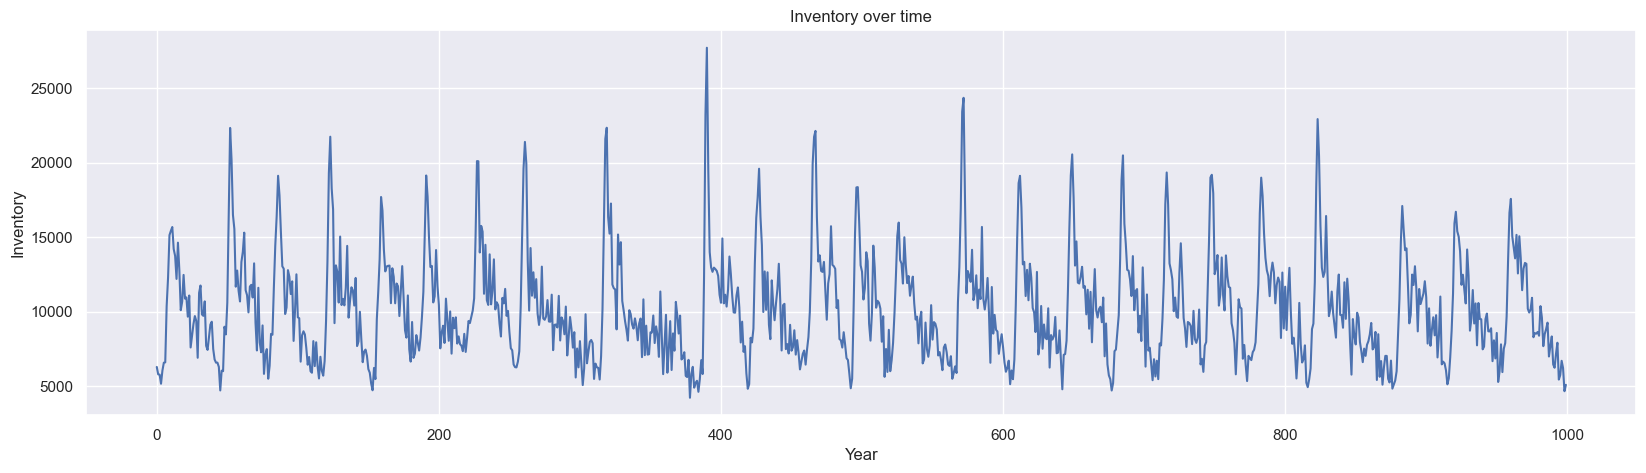

In [28]:
plot_yearly(df_monthly, 'Inventory', to_year=1000)

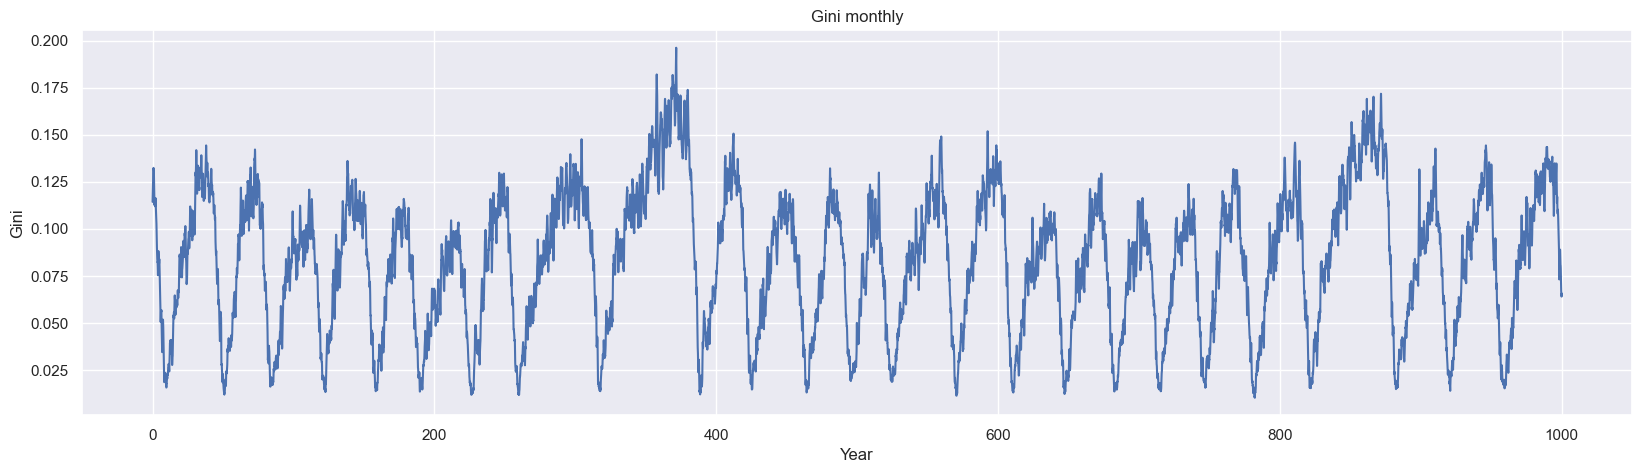

In [29]:
plot_monthly(df_monthly, 'Gini', to_year=1000)

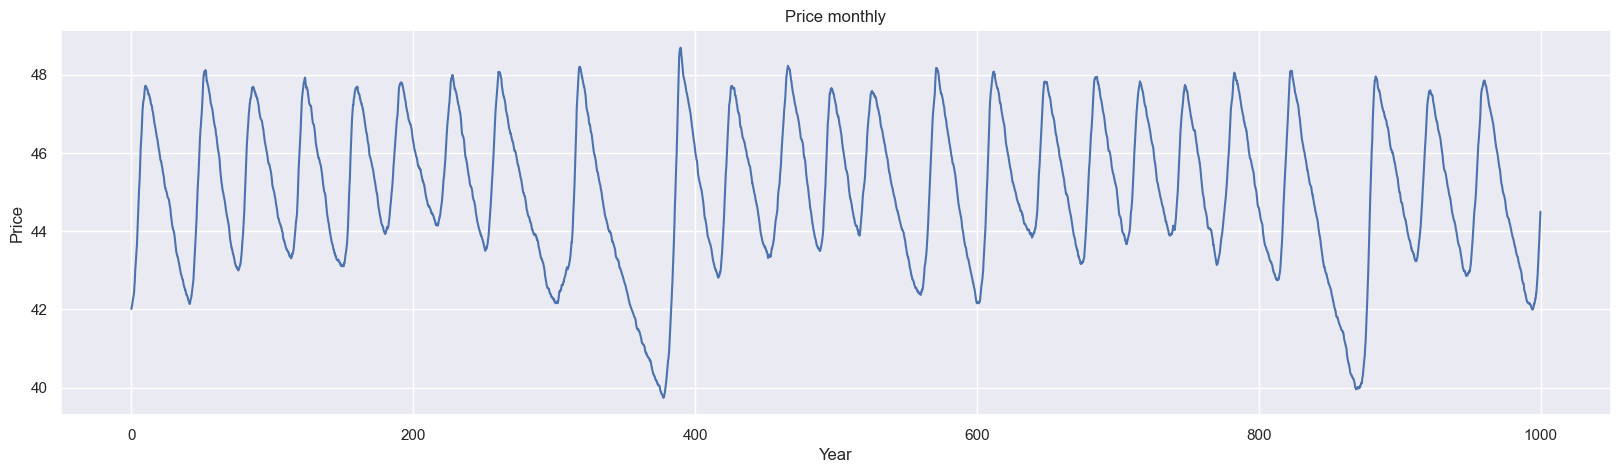

In [30]:
plot_monthly(df_monthly, 'Price', to_year=1000)

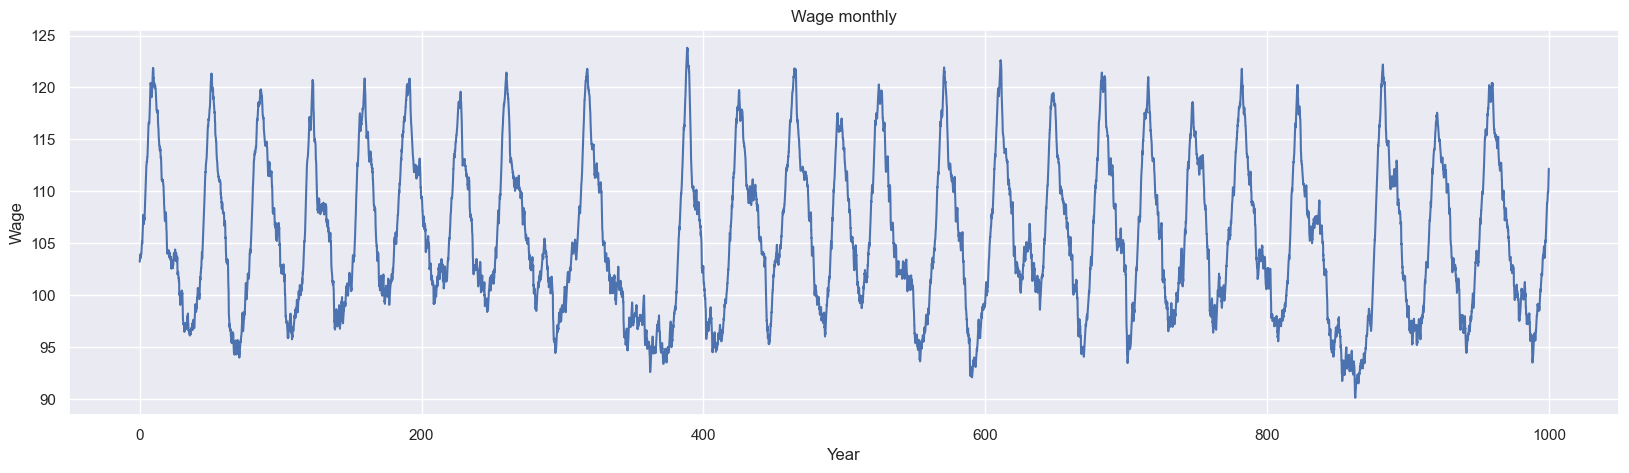

In [31]:
plot_monthly(df_monthly, 'Wage', to_year=1000)

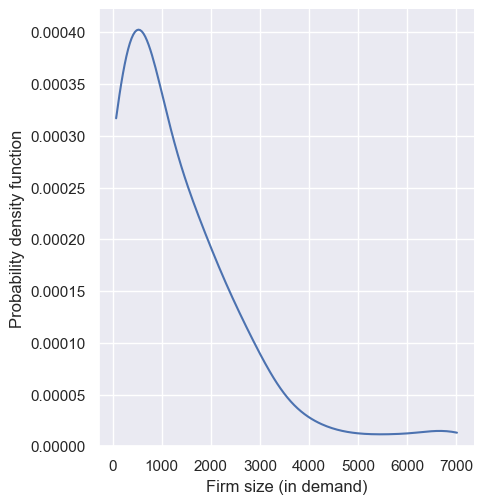

In [32]:
(sns.displot([firm.last_month_demand for firm in model.firms], kind="kde", cut=0)
    .set(xlabel='Firm size (in demand)')
    .set(ylabel='Probability density function'));

In [33]:
sum([hh.liquidity for hh in model.households] + [f.liquidity for f in model.firms] + [f.liquidity_buffer for f in model.firms])

5000000.000000128

In [34]:
sorted([f.last_month_demand for f in model.firms])

[72.75597102921452,
 90.8104168248561,
 153.0377913905997,
 188.80671485845568,
 191.65853407343155,
 195.31442278066336,
 196.9131076226229,
 201.85018008493063,
 204.72415599902925,
 218.77631919850188,
 226.71446812205582,
 227.24146439143016,
 248.61053899451142,
 250.82793936970805,
 262.928078064947,
 265.7562021143442,
 292.7697413642752,
 302.5266676226812,
 304.87874365769716,
 315.24654125716114,
 316.7619888189996,
 324.42620151003894,
 328.39016923337454,
 349.63593760986527,
 353.332875647026,
 362.38653680735473,
 384.1680037693378,
 400.7458723046271,
 400.8813644733881,
 406.360021890472,
 438.82121391798705,
 448.6071452416774,
 473.3539949652261,
 477.82016374048237,
 478.4754002825417,
 484.41427778589787,
 496.2640928822785,
 518.8332036986977,
 526.8939398664464,
 548.6379787501019,
 558.76720477511,
 564.7739889938458,
 573.229125694048,
 605.306867623317,
 624.0099341885366,
 635.1661255161666,
 642.7948324414921,
 755.9636865574417,
 819.9218828284738,
 849.3091